# Aisle Diversity and User Reorder Rate

The customer segmentation team wants to determine whether users who shop from a wider variety of aisles have higher reorder rates.

For each user, the analysis calculates:

- **Unique aisle count:** number of distinct aisles represented in the user's prior purchases.
- **Overall reorder rate:** mean of the item-level `reordered` indicator across the user's prior purchases.

The overall correlation provides an initial view of the relationship. However, users with longer shopping histories naturally have more opportunities to visit additional aisles and accumulate repeat purchases.

The analysis therefore also calculates each user's total number of prior orders and estimates the partial correlation between aisle diversity and reorder rate after accounting for this measure of user activity.

Correlation: 0.314


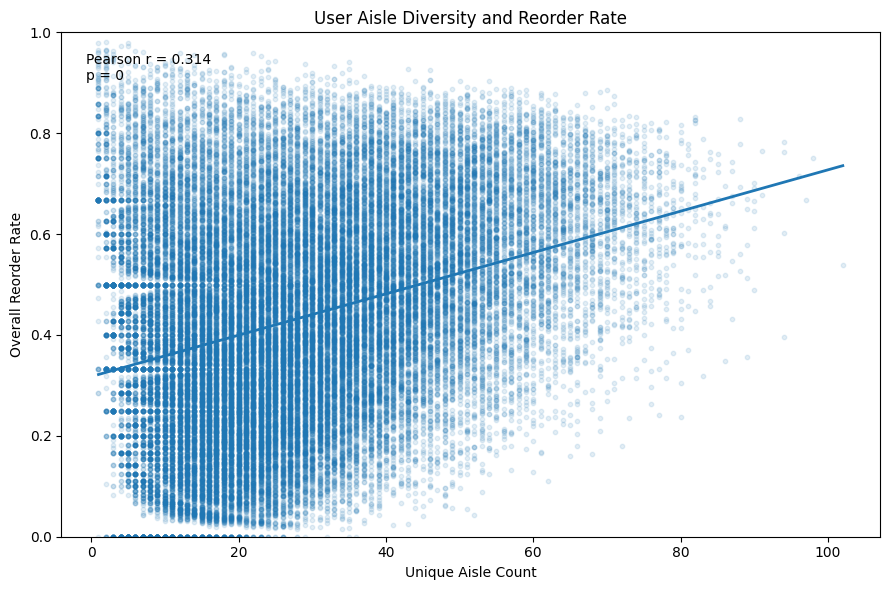

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


DATA_DIR = "../../data/shop"


# Load required data.
orders = pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=["order_id", "user_id", "eval_set"],
)

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=[
        "order_id",
        "product_id",
        "reordered",
    ],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "aisle_id"],
)


# Add user and aisle information.
prior_orders = orders[
    orders["eval_set"].eq("prior")
][["order_id", "user_id"]]

purchases = (
    order_products
    .merge(
        prior_orders,
        on="order_id",
        how="inner",
    )
    .merge(
        products,
        on="product_id",
        how="left",
    )
    .dropna(subset=["aisle_id"])
)


# Calculate user-level measures.
user_metrics = (
    purchases
    .groupby("user_id")
    .agg(
        unique_aisle_count=(
            "aisle_id",
            "nunique",
        ),
        reorder_rate=(
            "reordered",
            "mean",
        ),
    )
    .reset_index()
)


# Correlation between aisle diversity and reorder rate.
correlation, p_value = pearsonr(
    user_metrics["unique_aisle_count"],
    user_metrics["reorder_rate"],
)


print(
    "Correlation:",
    f"{correlation:.3f}",
)

# Visualization.
plot_data = user_metrics.sample(
    n=min(50_000, len(user_metrics)),
    random_state=42,
)

x = plot_data["unique_aisle_count"]
y = plot_data["reorder_rate"]

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    x,
    y,
    alpha=0.12,
    s=10,
)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
)

ax.set_title(
    "User Aisle Diversity and Reorder Rate"
)

ax.set_xlabel(
    "Unique Aisle Count"
)

ax.set_ylabel(
    "Overall Reorder Rate"
)

ax.set_ylim(0, 1)

ax.text(
    0.03,
    0.96,
    (
        f"Pearson r = {correlation:.3f}\n"
        f"p = {p_value:.3g}"
    ),
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout()
plt.show()

## Conclusion

The user-level analysis shows a moderate positive correlation between unique aisle count and overall reorder rate (Pearson correlation = **0.314**).

This suggests that users who shop from a wider variety of aisles tend to have higher reorder rates on average. The observed relationship provides evidence that broader shopping tastes are associated with greater customer loyalty.

The results indicate that aisle diversity may serve as a useful behavioral indicator for identifying customers who are more likely to make repeat purchases and could be incorporated into customer segmentation and personalized promotion strategies.